<a href="https://colab.research.google.com/github/Montasir00/Ml_final_project/blob/monti/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Project**

Team members:
1. Pham Gia Khiem - 551026 (Vietnam)
2. Mohammed Hassan – 541140 (Bangladesh)
3. Fazlur Rahman - 541927 (Bangladesh)

### Libraries

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

### Understanding the dataset

### Loading the dataset

In [21]:
df = pd.read_csv('final_project_dataset_complete.csv', index_col = False)
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0
...,...,...,...,...,...,...,...,...,...,...,...
8995,0.101630,0.400250,NaN,-0.019412,-0.063150,0.077627,0.540975,-0.169030,Above Average,Region A,0
8996,1.167218,2.177774,-1.716067,1.994835,0.350043,-0.544915,0.089050,-0.944220,High,Region C,1
8997,1.588447,3.333945,-2.615488,3.476880,-0.933276,2.027658,0.239583,1.951491,High,Region C,1
8998,-0.684987,-1.599835,1.063341,-1.252109,-0.724001,2.228943,0.989794,1.936476,Low,Region B,0


In [29]:
# Describe each feature
for column in df.columns:
    print(f"Feature: {column}")
    print(df[column].value_counts() if df[column].dtype == 'object' else df[column].describe())
    print("\n")

Feature: feature_1
count    9000.000000
mean        0.000427
std         1.241318
min       -18.665400
25%        -0.680062
50%        -0.003938
75%         0.680513
max        21.934496
Name: feature_1, dtype: float64


Feature: feature_2
count    9000.000000
mean        0.003349
std         2.508324
min       -37.852816
25%        -1.382610
50%        -0.016698
75%         1.380228
max        47.603454
Name: feature_2, dtype: float64


Feature: feature_3
count    8600.000000
mean        0.003235
std         1.542901
min        -6.676680
25%        -1.022085
50%         0.005196
75%         1.038571
max         6.203055
Name: feature_3, dtype: float64


Feature: feature_4
count    9000.000000
mean       -0.008481
std         2.061784
min        -8.190124
25%        -1.399928
50%        -0.019541
75%         1.394151
max         8.189001
Name: feature_4, dtype: float64


Feature: feature_5
count    9000.000000
mean       -0.002177
std         0.577415
min        -0.999791
25%        -0

In [22]:
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


In [24]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,8600.000000,9000.000000,9000.000000,8500.000000,9000.000000,9000.000000,9000.000000
mean,0.000427,0.003349,0.003235,-0.008481,-0.002177,-0.006447,0.000592,0.003348,0.475444
std,1.241318,2.508324,1.542901,2.061784,0.577415,1.981615,1.075064,2.043643,0.499424
min,-18.665400,-37.852816,-6.676680,-8.190124,-0.999791,-8.590782,-4.422265,-9.474989,0.000000
25%,-0.680062,-1.382610,-1.022085,-1.399928,-0.502614,-1.329040,-0.700078,-1.356620,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.680513,1.380228,1.038571,1.394151,0.497004,1.324897,0.731942,1.402024,1.000000
max,21.934496,47.603454,6.203055,8.189001,0.999914,6.803751,3.857219,7.572578,1.000000


In [25]:
# Checking for missing values
df.isnull().sum()

feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64

In [26]:
# Checking the number of unique values in each column to identify categorical features.
df.nunique()

feature_1     9000
feature_2     9000
feature_3     8600
feature_4     9000
feature_5     9000
feature_6     8500
feature_7     9000
feature_8     9000
category_1       4
category_2       3
target           2
dtype: int64

In [86]:
# Calculates the number of duplicate rows in the DataFrame df.
df.duplicated().sum()

0

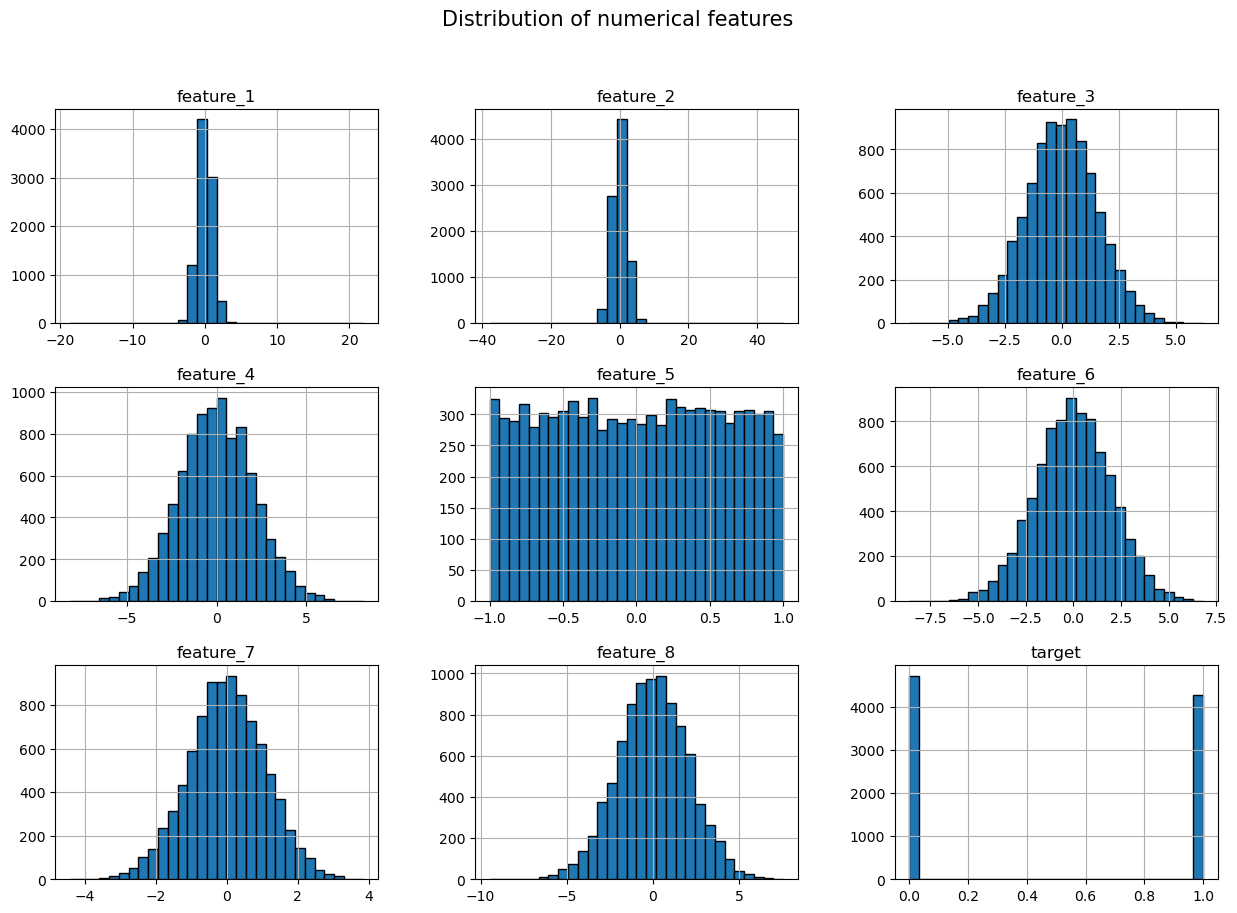

In [13]:
# Visualize the distribution of numerical features in the DataFrame
df.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

Text(0.5, 1.0, 'Box plot of numerical features')

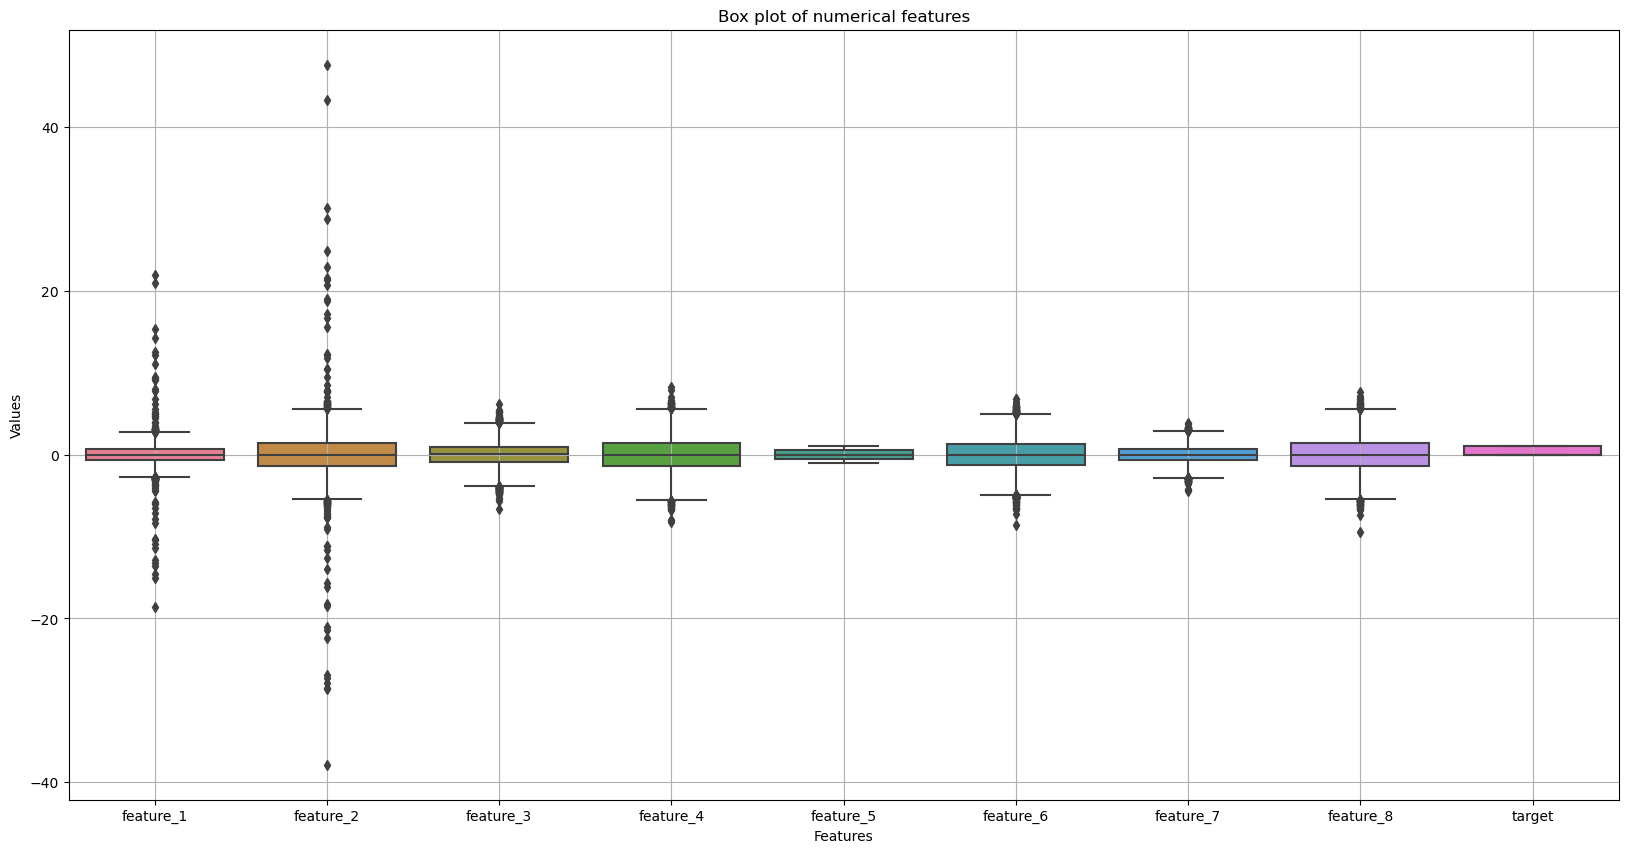

In [89]:
# Visualize the distribution of numerical features in the DataFrame using boxplot
plt.figure(figsize =(20, 10))
sns.boxplot(data = df, palette="husl")
# Add gridlines to the plot
plt.grid(True)

# Add labels and title
plt.xlabel("Features")
plt.ylabel("Values")
plt.title('Box plot of numerical features')

In [45]:
# Select only columns with numerical data types (float64 and int64) 
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [47]:
numeric_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0


In [42]:
#  Calculating the correlation matrix for the DataFrame
corr_matrix_cleaned = numeric_df.corr()

In [43]:
corr_matrix_cleaned

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.995360,-0.831705,0.831922,-0.015305,-0.010813,-0.010843,-0.004581,0.605940
feature_2,0.995360,1.000000,-0.823242,0.832002,-0.014715,-0.011519,-0.011393,-0.005394,0.606016
feature_3,-0.831705,-0.823242,1.000000,-0.957222,0.011309,0.003989,0.006042,0.001846,-0.704351
feature_4,0.831922,0.832002,-0.957222,1.000000,-0.003613,-0.000213,-0.001369,0.001202,0.694885
feature_5,-0.015305,-0.014715,0.011309,-0.003613,1.000000,-0.009365,0.252371,-0.012717,-0.007873
feature_6,-0.010813,-0.011519,0.003989,-0.000213,-0.009365,1.000000,0.921569,0.969998,0.001457
feature_7,-0.010843,-0.011393,0.006042,-0.001369,0.252371,0.921569,1.000000,0.894220,-0.002000
feature_8,-0.004581,-0.005394,0.001846,0.001202,-0.012717,0.969998,0.894220,1.000000,0.004658
target,0.605940,0.606016,-0.704351,0.694885,-0.007873,0.001457,-0.002000,0.004658,1.000000


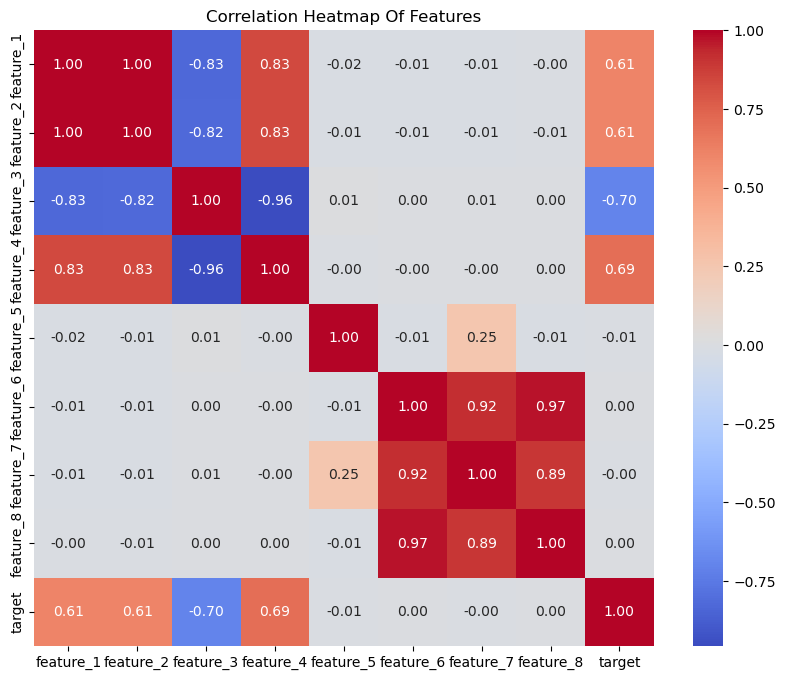

In [44]:
# Visualizing the correlation matrix heatmap
fig = plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix_cleaned, annot=True, cmap ='coolwarm',fmt='0.2f')
plt.title('Correlation Heatmap Of Features')
plt.show()


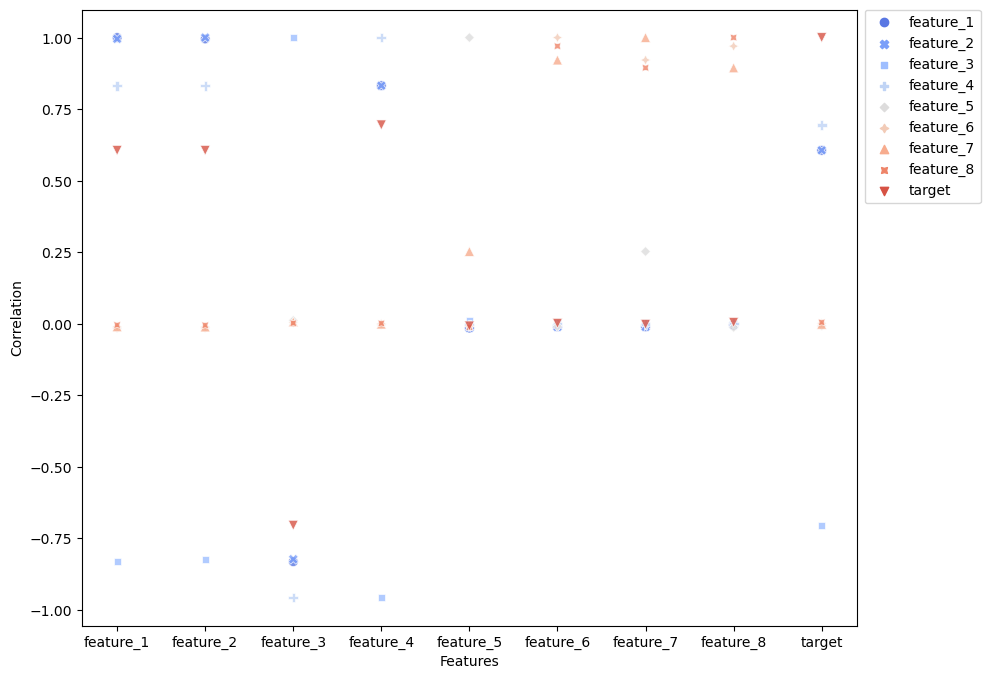

In [75]:
# Create a figure with specified size
fig, ax = plt.subplots(figsize=(10, 8))
# Visualizing the correlation between features and target using scatterplot
sns.scatterplot(data=corr_matrix_cleaned, palette='coolwarm', alpha=0.8, s=50, ax=ax)

ax.set_xlabel('Features')
ax.set_ylabel('Correlation')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0) 

# Show the plot
plt.show()

### Data Preprocessing

In [76]:
# Checking for missing values
df.isna().sum()

feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64

In [77]:
# assigning missing values to a variable
missing_values = df.isna().sum()

# Display columns with missing values
missing_values = missing_values[missing_values > 0]
print(missing_values)

feature_3    400
feature_6    500
dtype: int64


### Handling missing values of Numerical Features

In [82]:
# Using SimpleImputer class to fill in missing values(NaN) with median of each column
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['feature_3'] = imputer.fit_transform(df[['feature_3']])
df['feature_6'] = imputer.fit_transform(df[['feature_6']])

In [83]:
# Checking to see if any messing values left or not 
df['feature_3'].isna().sum()
df['feature_6'].isna().sum()

0

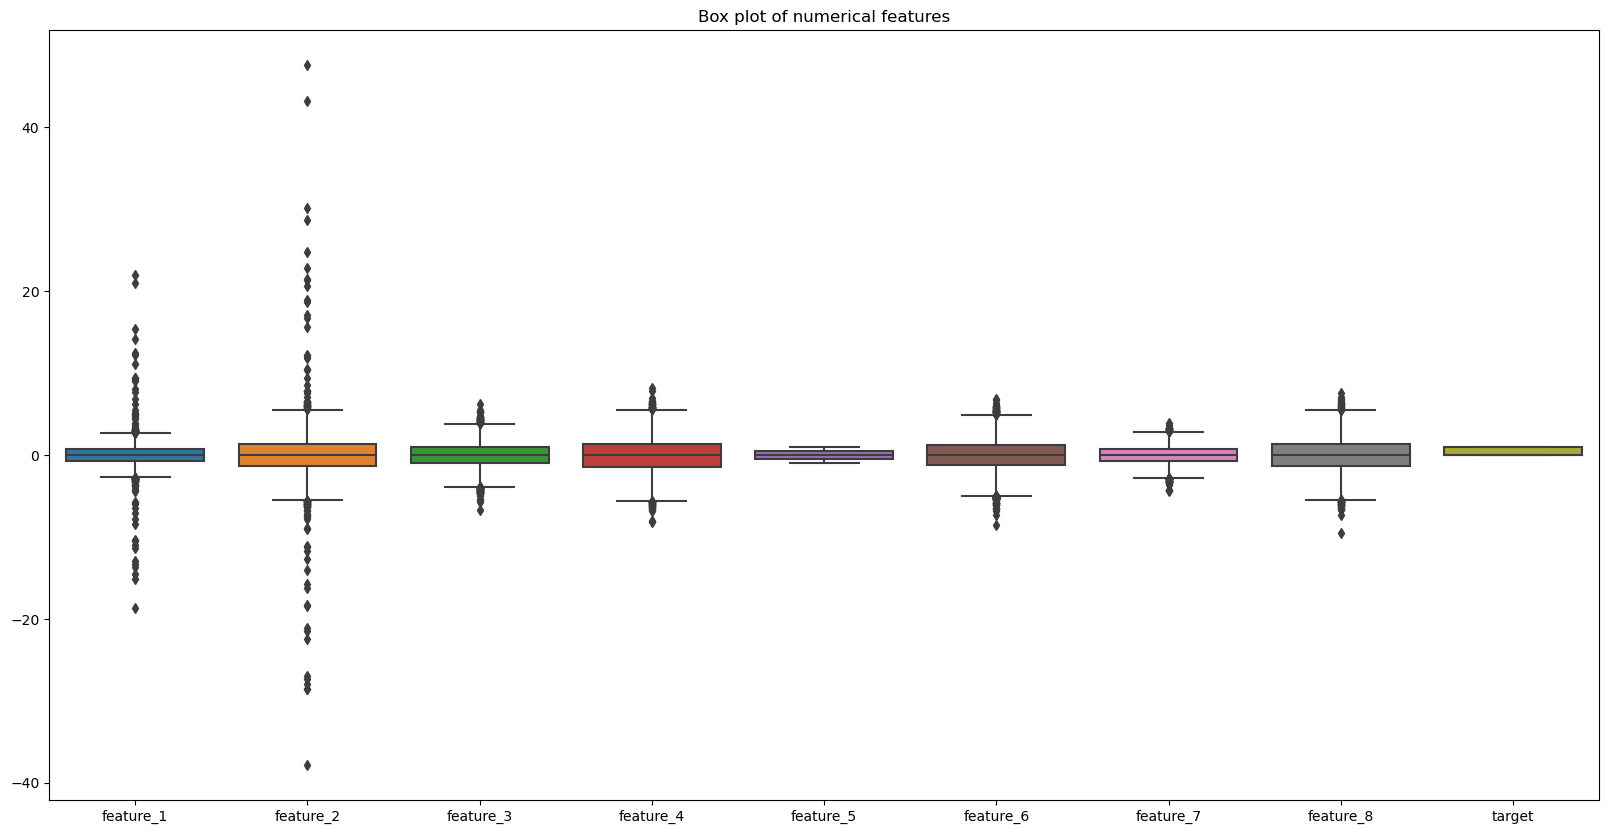

In [114]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(20,10))
plt.title('Box plot of numerical features')
sns.boxplot(data=numerical_features)
plt.show()

In [116]:
def iqr_outliers(dataset, feature_name, multiplier=1.5):
    # Calculate IQR
    Q1 = dataset[feature_name].quantile(0.25)
    Q3 = dataset[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate limits
    lower_limit = Q1 - multiplier * IQR
    upper_limit = Q3 + multiplier * IQR
    
    # Identify outliers
    outliers = dataset[(dataset[feature_name] < lower_limit) | (dataset[feature_name] > upper_limit)]
    
    return outliers, {'lower_limit': lower_limit, 'upper_limit': upper_limit}

outliers_detected = {}

for feature in numerical_features.columns:  
    outliers, limits = iqr_outliers(numerical_features, feature)
    outliers_detected[feature] = {
        'count': len(outliers),
        'indices': outliers.index.tolist(),
        'limits': limits
    }
    
    print(f'Feature: {feature}')
    print(f'Number of outliers: {len(outliers)}')
    print(f'Lower limit: {limits["lower_limit"]}, Upper limit: {limits["upper_limit"]}')
    print(f'Outlier indices: {outliers.index.tolist()}')
    print('-' * 50)


Feature: feature_1
Number of outliers: 113
Lower limit: -2.7209235765630777, Upper limit: 2.7213742002161805
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Number of outliers: 106
Lower limit: -5.526868048459379, Upper limit: 5.524485931793154
Outlier indices: [209, 262, 277, 469, 478, 49